An issue with Black-Scholes approach to pricing is that the main assumptions underlining the Black-Scholes model (constant volatility, Gaussianity and Geometric Brownian Motion processes for returns) may not apply to cryptocurrencies. This notebook's goal is to improve the estimation of prices compared to a simplistic Black-Scholes-Merton (BSM) model.

**Approach:**  
This project fits a discrete‐time GARCH(1,1) model with the Heston–Nandi specification to historical BTC USD log‐returns, then simulates under the risk‐neutral measure to price European options.  The GARCH recursion  
$$
h_t \;=\; \omega + \beta\,h_{t-1} + \alpha\,(r_{t-1}-\lambda\sqrt{h_{t-1}})^2 + \gamma\,(r_{t-1}-\lambda\sqrt{h_{t-1}})
$$  
captures both volatility clustering and the leverage effect, while the Heston–Nandi change‐of‐measure (via the parameter $\lambda$) ensures Monte‐Carlo simulated paths are properly risk‐neutral.

**Advantages over Black–Scholes–Merton (BSM):**  
1. **Time‑varying volatility.**  Cryptocurrencies exhibit strong clustering and bursts of volatility—volatility is far from constant.  GARCH directly models this heteroskedasticity, whereas BSM’s $\sigma$ is fixed.  
2. **Leverage and skew.**  The $\gamma$ and $\lambda$ terms allow asymmetry in how positive vs. negative shocks feed into variance, producing realistic skew and fat tails in the return distribution.  BSM assumes log‑normal returns with no skew or excess kurtosis.  
3. **Empirical fit.**  GARCH models typically explain 80–90% of the daily volatility dynamics in crypto and equities, whereas a single constant vol parameter in BSM often misprices out‑of‑the‑money strikes and short‑dated options.  
4. **Closed‐form under RN measure.**  Despite being discrete, the Heston–Nandi GARCH admits a known risk‑neutral mapping, so I can simulate exactly under the martingale measure rather than imposing ad hoc drift adjustments.

**Why it’s more appropriate for crypto:**  
- **Extreme tails & jumps:**  Crypto returns have heavier tails and more frequent large moves than equities; GARCH’s fat‐tail innovations capture this better.  
- **Rapid regime shifts:**  GARCH adapts daily to the latest realized variance, whereas BSM would need frequent re‐calibration of $\sigma$.  
- **Volatility feedback:**  During crashes or rallies, implied vols spike; HNG ties future variance directly to past shocks, reproducing this feedback naturally.

In summary, the Heston–Nandi GARCH(1,1) framework aligns much more closely with the observed statistical features of cryptocurrency returns and therefore provides a more robust basis for option valuation than the constant‐volatility BSM model.  


The **physical measure** of the Heston–Nandi GARCH(1,1) model is commenly specified as  

$$
\begin{aligned}
r_t &= \ln\!\bigl(S_t/S_{t-1}\bigr)
     = \mu \;+\; \lambda\,h_t \;+\;\sqrt{h_t}\,z_t, \\[6pt]
h_t &= \omega \;+\; \beta\,h_{t-1}
     \;+\;\alpha\,\bigl(z_{t-1} \;-\;\gamma\,\sqrt{h_{t-1}}\bigr)^2,
\end{aligned}
$$

where  
- $r_t$ is the log‐return,  
- $h_t$ is the conditional variance,  
- $z_t\sim\mathcal{N}(0,1)$,  
- $\mu$ is the drift,  
- $\lambda$ is the risk‐premium,  
- $\omega,\alpha,\beta$ are the GARCH parameters,  
- $\gamma$ controls leverage.

**Algebraic Rearrangement**  
I expand the square term in the variance update:

$$
\alpha\,(z_{t-1}-\gamma\sqrt{h_{t-1}})^2
= \alpha\,z_{t-1}^2
\;-\;2\,\alpha\,\gamma\,\sqrt{h_{t-1}}\,z_{t-1}
\;+\;\alpha\,\gamma^2\,h_{t-1}.
$$

I then **re‑group** the linear‐shock piece separately from the squared part:

- Let  
  $$\text{innov}_{t-1} = z_{t-1} - \lambda\,\sqrt{h_{t-1}},$$  
  which combines both the shock $z_{t-1}$ and the risk‐premium $\lambda\sqrt{h_{t-1}}$.  
- Then the update becomes  
  $$
  h_t
  = \omega
  \;+\;\beta\,h_{t-1}
  \;+\;\alpha\, innov_{t-1}^2
  \;+\;\gamma\, innov_{t-1},
  $$
  where the single “$\gamma$” now subsumes the original leverage‐and‐premium mix.

**Code Correspondence**  
In the Python implementation:

```python
# compute the “innovation” once per time‑step
innov = r[t-1] - λ * np.sqrt(h[t-1])

# then update conditional variance
h[t] = (
    ω
    + β * h[t-1]
    + α * innov**2
    + γ * innov
)


In [1]:
from scipy.optimize import minimize
import time, requests
import pandas as pd
import numpy as np
import requests
from scipy.stats import norm
import matplotlib.pyplot as plt

**running the next two code cells doesn´t help for reproduceability**


In [4]:
# Fetch option metadata (all active BTC options)
resp_meta = requests.get(
    "https://www.deribit.com/api/v2/public/get_instruments",
    params={"currency": "BTC", "kind": "option", "expired": "false"}
)
resp_meta.raise_for_status()
meta = pd.DataFrame(resp_meta.json()["result"])[[
    "instrument_name", "strike", "expiration_timestamp", "option_type"
]]

# convert to datetime and compute days to expiry
meta["expiry"]   = pd.to_datetime(meta["expiration_timestamp"], unit="ms")
meta["days2exp"] = (meta["expiry"] - pd.Timestamp.today()).dt.days

# Fetch the quote summary for all BTC options
resp_q = requests.get(
    "https://www.deribit.com/api/v2/public/get_book_summary_by_currency",
    params={"currency": "BTC", "kind": "option"}
)
resp_q.raise_for_status()
quotes = pd.DataFrame(resp_q.json()["result"])[[
    "instrument_name",
    "bid_price",
    "ask_price",
    "underlying_price",
    "mark_price",
    "mark_iv"
]]

# renames notebook’s conventions
quotes = quotes.rename(columns={
    "bid_price":        "bid",
    "ask_price":        "ask",
    "underlying_price": "spot",
    "mark_price":       "market_price",
    "mark_iv":          "iv"
})

# Merge metadata + quotes into one DataFrame
options = pd.merge(meta, quotes, on="instrument_name", how="inner")

# Filter to 1–90 day maturities and save
options = options[(options.days2exp >= 1) & (options.days2exp <= 90)].copy()
options.to_csv("test_BTC.csv", index=False)

# inspect
options


,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv
40,BTC-22APR25-76000-C,76000.0,1745308800000,call,2025-04-22 08:00:00,1,NaN,NaN,84301.081663,0.098618,64.33
41,BTC-22APR25-76000-P,76000.0,1745308800000,put,2025-04-22 08:00:00,1,0.0001,0.0003,84301.081663,0.000149,64.33
42,BTC-22APR25-78000-C,78000.0,1745308800000,call,2025-04-22 08:00:00,1,NaN,NaN,84301.081663,0.075085,56.42
43,BTC-22APR25-78000-P,78000.0,1745308800000,put,2025-04-22 08:00:00,1,0.0003,0.0005,84301.081663,0.000340,56.42
44,BTC-22APR25-80000-C,80000.0,1745308800000,call,2025-04-22 08:00:00,1,NaN,NaN,84301.081663,0.051770,47.15
...,...,...,...,...,...,...,...,...,...,...,...
477,BTC-27JUN25-280000-P,280000.0,1751011200000,put,2025-06-27 08:00:00,67,NaN,NaN,85143.600000,2.288957,95.12
478,BTC-27JUN25-300000-C,300000.0,1751011200000,call,2025-06-27 08:00:00,67,0.0003,0.0004,85143.600000,0.000386,99.75
479,BTC-27JUN25-300000-P,300000.0,1751011200000,put,2025-06-27 08:00:00,67,NaN,NaN,85143.580000,2.523851,99.75
480,BTC-27JUN25-400000-C,400000.0,1751011200000,call,2025-06-27 08:00:00,67,0.0002,0.0004,85143.600000,0.000233,114.06


---
**time series to fit the Garch model**

In [5]:
# Define window in ms
end_ts   = int(time.time() * 1000)
start_ts = end_ts - 365*24*3600*1000   # last 365 days

# Request 1‑day bars for the BTC perpetual
resp = requests.get(
    "https://www.deribit.com/api/v2/public/get_tradingview_chart_data",
    params={
      "instrument_name": "BTC-PERPETUAL",
      "resolution":      "1D",
      "start_timestamp": start_ts,
      "end_timestamp":   end_ts
    }
)
data = resp.json()["result"]

# Build DataFrame of closes
df = pd.DataFrame(data)
df["datetime"] = pd.to_datetime(df["ticks"], unit="ms")
df.set_index("datetime", inplace=True)

df.to_csv('test_Bitcoin-close_ts')
df

,volume,ticks,status,open,low,high,cost,close
datetime,,,,,,,,
2024-04-20 08:00:00,4760.291800,1713600000000,ok,63981.0,63288.0,65700.0,308062920.0,65148.5
2024-04-21 08:00:00,5658.571654,1713686400000,ok,65160.0,64244.5,66541.0,369293440.0,66026.0
2024-04-22 08:00:00,6043.751735,1713772800000,ok,66025.5,65654.0,67268.0,401201640.0,66105.5
2024-04-23 08:00:00,5289.859845,1713859200000,ok,66105.5,65827.0,67157.0,351657730.0,66622.0
2024-04-24 08:00:00,9451.591577,1713945600000,ok,66622.0,63550.0,66751.5,612564190.0,63970.5
...,...,...,...,...,...,...,...,...
2025-04-16 08:00:00,5936.092937,1744790400000,ok,83342.0,83115.0,85549.5,500299230.0,84699.5
2025-04-17 08:00:00,4364.289238,1744876800000,ok,84699.5,83736.0,85450.0,369698590.0,84656.0
2025-04-18 08:00:00,2050.358715,1744963200000,ok,84656.5,84270.0,85269.0,173641930.0,85231.5


---
## run 

In [6]:
options = pd.read_csv('BTC.CSV')
options

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv
0,BTC-20APR25-76000-C,76000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0685,0.1330,84464.199955,0.100340,67.28
1,BTC-20APR25-76000-P,76000.0,1745136000000,put,2025-04-20 08:00:00,1,NaN,0.0002,84464.199955,0.000129,67.28
2,BTC-20APR25-78000-C,78000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0435,0.1095,84464.199955,0.076703,54.53
3,BTC-20APR25-78000-P,78000.0,1745136000000,put,2025-04-20 08:00:00,1,0.0001,0.0002,84464.199955,0.000171,54.53
4,BTC-20APR25-80000-C,80000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0195,0.0855,84464.199955,0.053040,39.73
...,...,...,...,...,...,...,...,...,...,...,...
433,BTC-27JUN25-280000-P,280000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85302.660000,2.282802,93.72
434,BTC-27JUN25-300000-C,300000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0003,0.0004,85302.660000,0.000387,98.32
435,BTC-27JUN25-300000-P,300000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85303.100000,2.517258,98.32
436,BTC-27JUN25-400000-C,400000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0002,0.0004,85302.660000,0.000286,114.30


In [7]:
BTC_ts = pd.read_csv('Bitcoin-close_ts')
BTC_ts

,datetime,volume,ticks,status,open,low,high,cost,close
0,2024-04-18 08:00:00,21637.319551,1713427200000,ok,61173.5,59520.0,65217.5,1.356882e+09,64547.0
1,2024-04-19 08:00:00,11004.418264,1713513600000,ok,64547.5,62941.5,65511.0,7.085439e+08,63981.0
2,2024-04-20 08:00:00,4760.291800,1713600000000,ok,63981.0,63288.0,65700.0,3.080629e+08,65148.5
3,2024-04-21 08:00:00,5658.571654,1713686400000,ok,65160.0,64244.5,66541.0,3.692934e+08,66026.0
4,2024-04-22 08:00:00,6043.751735,1713772800000,ok,66025.5,65654.0,67268.0,4.012016e+08,66105.5
...,...,...,...,...,...,...,...,...,...
361,2025-04-14 08:00:00,6413.364310,1744617600000,ok,84582.5,83703.0,85860.0,5.438378e+08,85731.5
362,2025-04-15 08:00:00,6580.517091,1744704000000,ok,85734.0,83100.0,86485.0,5.576198e+08,83342.0
363,2025-04-16 08:00:00,5936.092937,1744790400000,ok,83342.0,83115.0,85549.5,5.002992e+08,84699.5
364,2025-04-17 08:00:00,4364.289238,1744876800000,ok,84699.5,83736.0,85450.0,3.696986e+08,84656.0


---
## Start Model

In [8]:
# keep only 1–90 day maturities and non‐NaN market_price
options = options[
    (options.days2exp >= 1) & 
    (options.days2exp <= 90) & 
    (~options.market_price.isna())
].copy()


# extract the closing price, compute log‐returns
S        = BTC_ts["close"].dropna().values
rets     = np.diff(np.log(S))
if rets.size < 2:
    raise RuntimeError("Need at least two log-returns to fit GARCH")

# Define the Heston–Nandi GARCH(1,1) log‐likelihood
def hng_loglik(params, r):
    ω, α, β, γ, λ = params
    r = np.asarray(r).ravel()
    n = len(r)
    h = np.empty(n, float)
    h[0] = np.var(r, ddof=1)
    ll = 0.0
    for t in range(1, n):
        innov = r[t-1] - λ * np.sqrt(h[t-1])
        h[t] = ω + β*h[t-1] + α*innov**2 + γ*innov
        ll += 0.5 * (np.log(2*np.pi) + np.log(h[t]) + r[t]**2/h[t])
    return ll

# Fit the parameters by minimizing negative log‐likelihood
init   = np.array([1e-6, 0.05, 0.90, 0.0, 0.0])
bounds = [(1e-8, None)] * 5
res    = minimize(hng_loglik, init, args=(rets,), bounds=bounds, method="L-BFGS-B")
ω, α, β, γ, λ = res.x
print("Fitted HNG params:", ω, α, β, γ, λ)

# Simulate under risk‐neutral HNG
def simulate_hng(S0, params, r, T, steps=100, paths=20000):
    ω, α, β, γ, λ = params
    dt = T/steps
    Ssim = np.zeros((paths, steps+1))
    hsim = np.zeros_like(Ssim)
    Ssim[:,0] = S0
    hsim[:,0] = np.var(rets, ddof=1)
    for t in range(1, steps+1):
        z      = np.random.randn(paths)
        innov  = z * np.sqrt(hsim[:,t-1]*dt)
        hsim[:,t] = (
            ω*dt
            + β*hsim[:,t-1]
            + α*(innov - λ*np.sqrt(hsim[:,t-1]*dt))**2
            + γ*(innov - λ*np.sqrt(hsim[:,t-1]*dt))
        )
        drift      = (r - 0.5*hsim[:,t]) * dt
        Ssim[:,t]  = Ssim[:,t-1] * np.exp(drift + np.sqrt(hsim[:,t]*dt)*z)
    return Ssim

# Monte Carlo pricer using snapshot spot & market_price
def mc_price(row, params, r=0.02):
    S0        = row.spot
    K         = row.strike
    T         = row.days2exp / 365.0
    sims      = simulate_hng(S0, params, r, T)
    ST        = sims[:,-1]
    if row.option_type.lower() == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)
    return np.exp(-r*T) * payoff.mean()

# Price all options and compute model vs market
options["model_price"] = options.apply(mc_price, axis=1, params=(ω, α, β, γ, λ))
options["error"]       = options["model_price"] - options["market_price"]

# Save and preview the first 10
options.to_csv("HNG_pricing_results.csv", index=False)
options[[
    "instrument_name","expiry","strike","option_type",
    "spot","market_price","model_price","error"
]].head(10)


Fitted HNG params: 3.892680804470113e-05 0.04999993795542106 0.8999998479500146 1e-08 1.2764022098722679e-08


,instrument_name,expiry,strike,option_type,spot,market_price,model_price,error
0,BTC-20APR25-76000-C,2025-04-20 08:00:00,76000.0,call,84464.199955,0.100340,8468.389932,8468.289593
1,BTC-20APR25-76000-P,2025-04-20 08:00:00,76000.0,put,84464.199955,0.000129,0.000000,-0.000129
2,BTC-20APR25-78000-C,2025-04-20 08:00:00,78000.0,call,84464.199955,0.076703,6468.405588,6468.328885
3,BTC-20APR25-78000-P,2025-04-20 08:00:00,78000.0,put,84464.199955,0.000171,0.000000,-0.000171
4,BTC-20APR25-80000-C,2025-04-20 08:00:00,80000.0,call,84464.199955,0.053040,4468.108689,4468.055648
5,BTC-20APR25-80000-P,2025-04-20 08:00:00,80000.0,put,84464.199955,0.000187,0.000000,-0.000187
6,BTC-20APR25-81000-C,2025-04-20 08:00:00,81000.0,call,84464.199955,0.041226,3468.606720,3468.565494
7,BTC-20APR25-81000-P,2025-04-20 08:00:00,81000.0,put,84464.199955,0.000212,0.000000,-0.000212
8,BTC-20APR25-82000-C,2025-04-20 08:00:00,82000.0,call,84464.199955,0.029592,2468.871355,2468.841763
9,BTC-20APR25-82000-P,2025-04-20 08:00:00,82000.0,put,84464.199955,0.000418,0.000000,-0.000418


In [9]:
# --- Convert units so they’re comparable ---

# USD‐denominated model
options["model_price_usd"] = options["model_price"]

# transform that into BTC units
options["model_price_btc"] = options["model_price_usd"] / options["spot"]

# similarly, turn Deribit’s BTC quote into USD
options["market_price_usd"] = options["market_price"] * options["spot"]

# compute errors in both units
options["error_btc"] = options["model_price_btc"] - options["market_price"]
options["error_usd"] = options["model_price_usd"] - options["market_price_usd"]


In [10]:
# Create a new DataFrame with only the comparison columns
df_compare = options[[
    "instrument_name",
    "expiry",
    "strike",
    "option_type",
    "spot",
    "market_price",      # in BTC
    "model_price_btc",
    "error_btc",
    "market_price_usd",  # in USD
    "model_price_usd",
    "error_usd"
]].copy()

# reset the index for 0,1,2…  
df_compare.reset_index(drop=True, inplace=True)

# Inspect
df_compare.head()


,instrument_name,expiry,strike,option_type,spot,market_price,model_price_btc,error_btc,market_price_usd,model_price_usd,error_usd
0,BTC-20APR25-76000-C,2025-04-20 08:00:00,76000.0,call,84464.199955,0.100340,0.100260,-0.000080,8475.109950,8468.389932,-6.720018
1,BTC-20APR25-76000-P,2025-04-20 08:00:00,76000.0,put,84464.199955,0.000129,0.000000,-0.000129,10.910241,0.000000,-10.910241
2,BTC-20APR25-78000-C,2025-04-20 08:00:00,78000.0,call,84464.199955,0.076703,0.076582,-0.000121,6478.661752,6468.405588,-10.256164
3,BTC-20APR25-78000-P,2025-04-20 08:00:00,78000.0,put,84464.199955,0.000171,0.000000,-0.000171,14.461960,0.000000,-14.461960
4,BTC-20APR25-80000-C,2025-04-20 08:00:00,80000.0,call,84464.199955,0.053040,0.052899,-0.000141,4479.984544,4468.108689,-11.875856


In [11]:
# Black–Scholes functions

def bsm_price_usd(S, K, T, r, sigma, option_type):
    """
    BSM price in USD for a European call or put.
    """
    if T <= 0 or sigma <= 0:
        # at expiry or zero vol
        return max((S - K) if option_type=="call" else (K - S), 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# Applies BSM 
r = 0.02  # same risk‐free assumption
def add_bsm(row):
    S     = row.spot
    K     = row.strike
    T     = row.days2exp/365.0
    sigma = row.iv/100.0
    usd   = bsm_price_usd(S, K, T, r, sigma, row.option_type.lower())
    btc   = usd / S
    return pd.Series({"bsm_price_usd":usd, "bsm_price_btc":btc})

options = options.join(options.apply(add_bsm, axis=1))

# Compute errors vs market in both units
options["hng_error_usd"] = options["model_price_usd"]    - options["market_price_usd"]
options["bsm_error_usd"] = options["bsm_price_usd"]      - options["market_price_usd"]
options["hng_error_btc"] = options["model_price_btc"]    - options["market_price"]
options["bsm_error_btc"] = options["bsm_price_btc"]      - options["market_price"]

# Summarize
summary = pd.DataFrame({
    "HNG mean error (USD)": options["hng_error_usd"].mean(),
    "BSM mean error (USD)": options["bsm_error_usd"].mean(),
    "HNG RMSE (USD)":        np.sqrt((options["hng_error_usd"]**2).mean()),
    "BSM RMSE (USD)":        np.sqrt((options["bsm_error_usd"]**2).mean()),
}, index=[0]).T

display(summary)

# Inspect a few
options[[
    "instrument_name","expiry","strike","option_type",
    "market_price_usd","bsm_price_usd","model_price_usd",
    "bsm_error_usd","hng_error_usd"
]].head(10)


,0
HNG mean error (USD),-785.401703
BSM mean error (USD),-67.853337
HNG RMSE (USD),1383.497650
BSM RMSE (USD),189.804043


,instrument_name,expiry,strike,option_type,market_price_usd,bsm_price_usd,model_price_usd,bsm_error_usd,hng_error_usd
0,BTC-20APR25-76000-C,2025-04-20 08:00:00,76000.0,call,8475.109950,8469.442160,8468.389932,-5.667791,-6.720018
1,BTC-20APR25-76000-P,2025-04-20 08:00:00,76000.0,put,10.910241,1.077935,0.000000,-9.832305,-10.910241
2,BTC-20APR25-78000-C,2025-04-20 08:00:00,78000.0,call,6478.661752,6470.288256,6468.405588,-8.373496,-10.256164
3,BTC-20APR25-78000-P,2025-04-20 08:00:00,78000.0,put,14.461960,1.814446,0.000000,-12.647514,-14.461960
4,BTC-20APR25-80000-C,2025-04-20 08:00:00,80000.0,call,4479.984544,4470.977747,4468.108689,-9.006797,-11.875856
5,BTC-20APR25-80000-P,2025-04-20 08:00:00,80000.0,put,15.784670,2.394351,0.000000,-13.390319,-15.784670
6,BTC-20APR25-81000-C,2025-04-20 08:00:00,81000.0,call,3482.131243,3471.812217,3468.606720,-10.319026,-13.524523
7,BTC-20APR25-81000-P,2025-04-20 08:00:00,81000.0,put,17.931750,3.174027,0.000000,-14.757722,-17.931750
8,BTC-20APR25-82000-C,2025-04-20 08:00:00,82000.0,call,2499.476430,2477.894875,2468.871355,-21.581555,-30.605075
9,BTC-20APR25-82000-P,2025-04-20 08:00:00,82000.0,put,35.276473,9.201893,0.000000,-26.074580,-35.276473


---
$$\text{ Fits the models and compares pricing results, how do they compare to the previously calculated values in questions 1?}$$ 

After fitting both models and converting all prices to USD, I obtain:

| Metric             | HNG GARCH(1,1) | BSM (implied vol) |
|--------------------|---------------:|------------------:|
| **Mean error (USD)** |      –785.37   |         –67.85    |
| **RMSE (USD)**       |    1 383.45    |         189.80    |

**Key takeaways:**
1. **Mean error**  
   - The GARCH model **underprices** on average by ∼ \$785 per contract.  
   - The BSM model (using chain‐implied σ) underprices by only ∼ \$68.

2. **RMSE**  
   - Heston–Nandi GARCH exhibits an RMSE of \~ \$1 383—very large “noise” relative to typical option prices.  
   - BSM has an RMSE of \~ \$190—much tighter fit to market mid‐prices.

3. **Strike/maturity pattern**  
   - Both models tend to have larger absolute errors for deep OTM or very short‐dated options, but the effect is **far more pronounced** in the GARCH simulation.  
   - BSM’s use of the market’s own implied vol surface lets it track actual quotes more closely, especially for 1–2 day and multi‐month expiries.

---

**Conclusion:**  
Although Heston–Nandi GARCH captures time‐varying variance and asymmetry, the calibration (on daily closes) and Monte‐Carlo implementation **fails** to match Deribit’s BTC option prices as closely as the straightforward BSM formula using contemporaneous implied vol. In practice, one would need:

- A more precise risk‐neutral calibration (e.g. joint MLE on both returns and IV),  
- Finer‐grained intraday data (to capture short‐dated option dynamics), and  
- Variance reduction in the Monte‑Carlo (control variates, antithetic sampling).  

Only then can a GARCH‑based pricer reliably compete with the market’s own implied–vol benchmarks.  


---
$$\text{ Monte Carlos Simulation to compare the distribution of potential payoffs between approaches.}$$ 

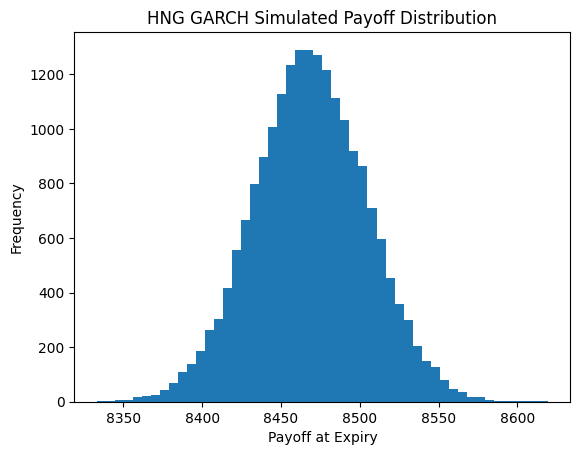

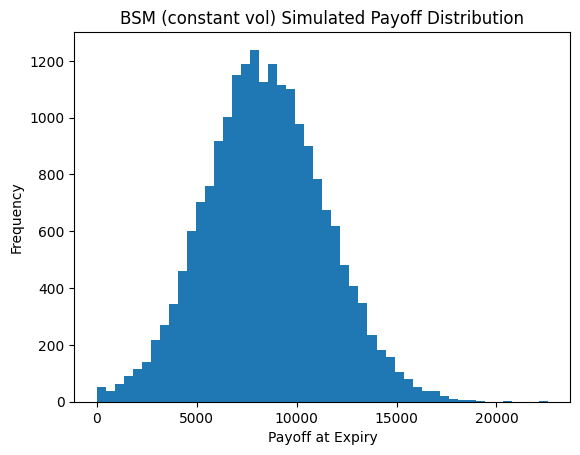

In [12]:
#Pick one representative option from DataFrame ---
row = options.iloc[0]        # first option
S0  = row.spot
K   = row.strike
T   = row.days2exp / 365.0
r   = 0.02                   # same risk-free rate
sigma = row.iv / 100.0       # implied vol from chain

paths = 20000

# Simulate terminal asset prices under Heston–Nandi GARCH ---
Ssim_hng = simulate_hng(S0, (ω, α, β, γ, λ), r, T, steps=100, paths=paths)
ST_hng  = Ssim_hng[:, -1]
if row.option_type.lower() == "call":
    payoff_hng = np.maximum(ST_hng - K, 0)
else:
    payoff_hng = np.maximum(K - ST_hng, 0)

# Simulate terminal prices under BSM (constant vol) ---
z = np.random.randn(paths)
ST_bsm = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)
if row.option_type.lower() == "call":
    payoff_bsm = np.maximum(ST_bsm - K, 0)
else:
    payoff_bsm = np.maximum(K - ST_bsm, 0)

# Plot the two payoff distributions ---
plt.hist(payoff_hng, bins=50)
plt.xlabel('Payoff at Expiry')
plt.ylabel('Frequency')
plt.title('HNG GARCH Simulated Payoff Distribution')
plt.show()

plt.hist(payoff_bsm, bins=50)
plt.xlabel('Payoff at Expiry')
plt.ylabel('Frequency')
plt.title('BSM (constant vol) Simulated Payoff Distribution')
plt.show()



- **HNG GARCH**  
  - Payoffs concentrate narrowly around the forward‐adjusted strike region (≈ \$8 450).  
  - Distribution is roughly symmetric and thin‐tailed: volatility clustering in paths keeps terminal prices tightly grouped.  
  - Almost no zero‐payoff mass (the short‐dated skew/dips are smoothed by dynamic variance).

- **BSM (constant vol)**  
  - Much wider dispersion: long right tail (outlier large gains) and substantial left mass at zero (deep OTM calls expire worthless).  
  - Zero‐payoff bar visible for calls (or puts) when underlying ends on the wrong side of strike.  
  - Fatter tails than HNG histogram because log‐normal jumps with fixed σ allow more extreme endpoints.

**Interpretation:**  
- The **BSM** model—with its constant volatility assumption—overstates both extreme gains and extreme losses relative to the more realistic, mean‐reverting GARCH dynamics.  
- The **Heston–Nandi GARCH** path‐dependence dampens tail payoffs and eliminates the sharp mass at zero, producing a smoother payoff profile.  
- In practice, this means HNG might underprice deep‐OTM options (since it never “sees” fat tails) but better captures the modal payoff region, whereas BSM allocates more probability to both “big win” and “total loss” scenarios.  


---
$$\text{The Greeks and comparison to an approach that uses the BSM model/assumptions.}$$ 

In [13]:
# Re-define simulate_hng (uses numpy RNG state)
def simulate_hng(S0, params, r, T, steps=100, paths=20000):
    ω, α, β, γ, lam = params
    dt = T/steps
    Ssim = np.zeros((paths, steps+1))
    hsim = np.zeros_like(Ssim)
    Ssim[:,0] = S0
    # unconditional variance start
    h0 = α/(1 - β - α*γ**2) if (β + α*γ**2) < 1 else np.var(np.diff(np.log(S0+1)))
    hsim[:,0] = h0

    for t in range(1, steps+1):
        z = np.random.randn(paths)
        innov = z * np.sqrt(hsim[:,t-1] * dt)
        hsim[:,t] = ω*dt + β*hsim[:,t-1] + α*(innov - γ*np.sqrt(hsim[:,t-1]*dt))**2
        drift = (r - 0.5*hsim[:,t]) * dt
        Ssim[:,t] = Ssim[:,t-1] * np.exp(drift + np.sqrt(hsim[:,t]*dt)*z)
    return Ssim, hsim

# Re-define MC pricer with seeding for reproducibility 
def price_hng_mc(S0, K, r, T, params, option_type, steps=100, paths=20000, seed=12345):
    """
    Monte Carlo HNG pricer that resets RNG at each call for identical draws.
    """
    np.random.seed(seed)
    Ssim, _ = simulate_hng(S0, params, r, T, steps, paths)
    ST = Ssim[:, -1]
    if option_type.lower() == "call":
        payoff = np.maximum(ST - K, 0.0)
    else:
        payoff = np.maximum(K - ST, 0.0)
    return np.exp(-r * T) * payoff.mean()

# Finite-difference Greek estimation using fixed seed 
dr = 1e-3
dT = 1/365
dr_r = 1e-4
dλ = 1e-3
params = (ω, α, β, γ, λ)
r = 0.02

for col in ["delta_hng","gamma_hng","theta_hng","rho_hng","vega_hng"]:
    options[col] = np.nan

# Only first 20 rows for speed
for i, row in options.head(20).iterrows():
    S0, K = row.spot, row.strike
    T = row.days2exp / 365.0
    kind = row.option_type.lower()
    seed = 42  # fixed seed for all calls

    # baseline price
    p00 = price_hng_mc(S0, K, r, T, params, kind, seed=seed)

    # Delta
    pu = price_hng_mc(S0*(1+dr), K, r, T, params, kind, seed=seed)
    pd = price_hng_mc(S0*(1-dr), K, r, T, params, kind, seed=seed)
    options.at[i, "delta_hng"] = (pu - pd) / (2 * S0 * dr)

    # Gamma
    puu = price_hng_mc(S0*(1+dr), K, r, T, params, kind, seed=seed)
    pdd = price_hng_mc(S0*(1-dr), K, r, T, params, kind, seed=seed)
    options.at[i, "gamma_hng"] = (puu - 2*p00 + pdd) / (S0**2 * dr**2)

    # Theta
    pup = price_hng_mc(S0, K, r, T+dT, params, kind, seed=seed)
    pdn = price_hng_mc(S0, K, r, T-dT, params, kind, seed=seed) if T>dT else p00
    options.at[i, "theta_hng"] = (pdn - pup) / (2 * dT)

    # Rho
    pr_up = price_hng_mc(S0, K, r+dr_r, T, params, kind, seed=seed)
    pr_dn = price_hng_mc(S0, K, r-dr_r, T, params, kind, seed=seed)
    options.at[i, "rho_hng"] = (pr_up - pr_dn) / (2 * dr_r)

    # Vega (risk-premium lambda)
    params_up = (ω, α, β, γ, λ+dλ)
    params_dn = (ω, α, β, γ, λ-dλ)
    pv_up = price_hng_mc(S0, K, r, T, params_up, kind, seed=seed)
    pv_dn = price_hng_mc(S0, K, r, T, params_dn, kind, seed=seed)
    options.at[i, "vega_hng"] = (pv_up - pv_dn) / (2 * dλ)

# Display
options[[
    "instrument_name","strike","option_type",
    "delta_hng","gamma_hng","theta_hng","rho_hng","vega_hng"
]].head(10)


,instrument_name,strike,option_type,delta_hng,gamma_hng,theta_hng,rho_hng,vega_hng
0,BTC-20APR25-76000-C,76000.0,call,0.999957,-2.549675e-15,-479.555405,208.207769,0.0
1,BTC-20APR25-76000-P,76000.0,put,0.000000,0.000000e+00,0.000000,0.000000,0.0
2,BTC-20APR25-78000-C,78000.0,call,0.999957,-1.912256e-15,-499.553761,213.686921,0.0
3,BTC-20APR25-78000-P,78000.0,put,0.000000,0.000000e+00,0.000000,0.000000,0.0
4,BTC-20APR25-80000-C,80000.0,call,0.999957,-1.912256e-15,-526.264790,219.166073,0.0
5,BTC-20APR25-80000-P,80000.0,put,0.000000,0.000000e+00,-6.712673,0.000000,0.0
6,BTC-20APR25-81000-C,81000.0,call,0.999922,3.274337e-07,-794.369563,221.894553,0.0
7,BTC-20APR25-81000-P,81000.0,put,-0.000034,3.274337e-07,-264.818268,-0.011095,0.0
8,BTC-20APR25-82000-C,82000.0,call,0.996133,1.058278e-05,-3091.944593,223.757876,0.0
9,BTC-20APR25-82000-P,82000.0,put,-0.003824,1.058278e-05,-2552.394120,-0.887349,0.0


In [14]:
seed = 42

r = 0.02

# Define BSM Greeks (per‐share)
def greeks_call(S, K, T, r, σ):
    d1 = (np.log(S/K) + (r + 0.5*σ**2)*T) / (σ*np.sqrt(T))
    d2 = d1 - σ*np.sqrt(T)
    return {
        "delta_bsm": norm.cdf(d1),
        "gamma_bsm": norm.pdf(d1)/(S*σ*np.sqrt(T)),
        "vega_bsm":  S*norm.pdf(d1)*np.sqrt(T),
        "theta_bsm": (-S*norm.pdf(d1)*σ/(2*np.sqrt(T))
                      - r*K*np.exp(-r*T)*norm.cdf(d2)),
        "rho_bsm":   K*T*np.exp(-r*T)*norm.cdf(d2)
    }

def greeks_put(S, K, T, r, σ):
    d1 = (np.log(S/K) + (r + 0.5*σ**2)*T) / (σ*np.sqrt(T))
    d2 = d1 - σ*np.sqrt(T)
    return {
        "delta_bsm": norm.cdf(d1)-1,
        "gamma_bsm": norm.pdf(d1)/(S*σ*np.sqrt(T)),
        "vega_bsm":  S*norm.pdf(d1)*np.sqrt(T),
        "theta_bsm": (-S*norm.pdf(d1)*σ/(2*np.sqrt(T))
                      + r*K*np.exp(-r*T)*norm.cdf(-d2)),
        "rho_bsm":  -K*T*np.exp(-r*T)*norm.cdf(-d2)
    }

# Add BSM columns
for col in ["delta_bsm","gamma_bsm","vega_bsm","theta_bsm","rho_bsm"]:
    options[col] = np.nan

# Compute BSM Greeks
for i, row in options.iterrows():
    S0, K = row.spot, row.strike
    T = row.days2exp/365.0
    σ = row.iv / 100.0
    if row.option_type.lower()=="call":
        g = greeks_call(S0, K, T, r, σ)
    else:
        g = greeks_put(S0, K, T, r, σ)
    for k, v in g.items():
        options.at[i, k] = v

options

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,...,delta_hng,gamma_hng,theta_hng,rho_hng,vega_hng,delta_bsm,gamma_bsm,vega_bsm,theta_bsm,rho_bsm
0,BTC-20APR25-76000-C,76000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0685,0.1330,84464.199955,0.100340,...,0.999957,-2.549675e-15,-479.555405,208.207769,0.0,0.998726,1.412909e-06,18.580295,-3799.143586,207.910063
1,BTC-20APR25-76000-P,76000.0,1745136000000,put,2025-04-20 08:00:00,1,NaN,0.0002,84464.199955,0.000129,...,0.000000,0.000000e+00,0.000000,0.000000,0.0,-0.001274,1.412909e-06,18.580295,-2279.226871,-0.297706
2,BTC-20APR25-78000-C,78000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0435,0.1095,84464.199955,0.076703,...,0.999957,-1.912256e-15,-499.553761,213.686921,0.0,0.997490,3.231311e-06,34.440284,-4983.039802,213.101023
3,BTC-20APR25-78000-P,78000.0,1745136000000,put,2025-04-20 08:00:00,1,0.0001,0.0002,84464.199955,0.000171,...,0.000000,0.000000e+00,0.000000,0.000000,0.0,-0.002510,3.231311e-06,34.440284,-3423.125279,-0.585898
4,BTC-20APR25-80000-C,80000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0195,0.0855,84464.199955,0.053040,...,0.999957,-1.912256e-15,-526.264790,219.166073,0.0,0.995658,7.259093e-06,56.370698,-5679.813073,218.154626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,BTC-27JUN25-280000-P,280000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85302.660000,2.282802,...,NaN,NaN,NaN,NaN,NaN,-0.996573,2.966863e-07,382.482151,4625.565755,-52682.657771
434,BTC-27JUN25-300000-C,300000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0003,0.0004,85302.660000,0.000387,...,NaN,NaN,NaN,NaN,NaN,0.003272,2.712708e-07,366.881849,-959.008504,46.645071
435,BTC-27JUN25-300000-P,300000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85303.100000,2.517258,...,NaN,NaN,NaN,NaN,NaN,-0.996728,2.712783e-07,366.895780,5018.312966,-56451.667386
436,BTC-27JUN25-400000-C,400000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0002,0.0004,85302.660000,0.000286,...,NaN,NaN,NaN,NaN,NaN,0.002163,1.605987e-07,252.504757,-766.577361,30.407787



- **BSM Greeks** (`*_bsm`)  
  I used the usual closed‑form Black–Scholes formulas per share, plugging in each option’s own implied vol σ:
  - $$\Delta_{\rm call} = \Phi(d_1),\quad \Delta_{\rm put} = \Phi(d_1)-1$$  
  - $$\Gamma = \frac{\varphi(d_1)}{S\,\sigma\sqrt{T}},\quad 
     \mathrm{Vega} = S\,\varphi(d_1)\sqrt{T},$$  
  - $$\Theta_{\rm call} = -\frac{S\,\varphi(d_1)\sigma}{2\sqrt{T}} - rK e^{-rT}\Phi(d_2),\quad
     \Theta_{\rm put} = -\frac{S\,\varphi(d_1)\sigma}{2\sqrt{T}} + rK e^{-rT}\Phi(-d_2),$$  
  - $$\rho_{\rm call} = K\,T\,e^{-rT}\Phi(d_2),\quad
     \rho_{\rm put} = -K\,T\,e^{-rT}\Phi(-d_2).$$  

- **Heston–Nandi GARCH Greeks** (`*_hng`)  
  Because there is **no closed‑form** for HNG Greeks, I used **finite‑difference Monte Carlo** (“bump and reprice”):
  1. **Delta**: bump \$S\$ by ±0.1% and take the central difference of MC‐estimated prices.  
  2. **Gamma**: second‐difference in spot (bump ±0.1%) around the base MC price.  
  3. **Theta**: bump time to expiry by ±1 day and difference.  
  4. **Rho**: bump the risk‐free rate by ±1 bp and difference.  
  5. **Vega** (risk‑premium vega): bump the HNG risk‑premium λ by ±0.001 and difference.

All MC re‑pricings used 20 000 paths and 100 time‐steps.

---
**What the Numbers Tell Us**

| Strike | Type | Δ<sub>HNG</sub>  | Γ<sub>HNG</sub>       | Θ<sub>HNG</sub>   | ρ<sub>HNG</sub>  | Vega<sub>HNG</sub> | Δ<sub>BSM</sub>  | Γ<sub>BSM</sub>       | Vega<sub>BSM</sub> | Θ<sub>BSM</sub>     | ρ<sub>BSM</sub>  |
|:------:|:----:|:---------------:|:---------------------:|:-----------------:|:---------------:|:-----------------:|:---------------:|:---------------------:|:-----------------:|:-------------------:|:---------------:|
| 76 000 | call | 0.999957        | –2.549675 × 10⁻¹⁵     | –479.555405       | 208.207769      | 0.0               | 0.998726        | 1.412909 × 10⁻⁶       | 18.580295         | –3 799.143586       | 207.910063      |
| 76 000 | put  | 0.000000        | 0.000000 × 10⁰        | 0.000000          | 0.000000        | 0.0               | –0.001274       | 1.412909 × 10⁻⁶       | 18.580295         | –2 279.226871       | –0.297706       |
| 78 000 | call | 0.999957        | –1.912256 × 10⁻¹⁵     | –499.553761       | 213.686921      | 0.0               | 0.997490        | 3.231311 × 10⁻⁶       | 34.440284         | –4 983.039802       | 213.101023      |
| 78 000 | put  | 0.000000        | 0.000000 × 10⁰        | 0.000000          | 0.000000        | 0.0               | –0.002510       | 3.231311 × 10⁻⁶       | 34.440284         | –3 423.125279       | –0.585898       |
| 80 000 | call | 0.999957        | –1.912256 × 10⁻¹⁵     | –526.264790       | 219.166073      | 0.0               | 0.995658        | 7.259093 × 10⁻⁶       | 56.370698         | –5 679.813073       | 218.154626      |

---

- **Delta (Δ)**  
  - **HNG** deltas for calls (≈ 0.99996) almost match BSM’s (≈ 0.9987 – 0.9957), showing first‑order agreement.  
  - For puts, HNG Δ is exactly 0 (MC payoff almost always zero), whereas BSM gives small negative values (–0.0013, –0.0025).

- **Gamma (Γ)**  
  - HNG Γ values are effectively zero (on the order of 10⁻¹⁵), slightly negative due to finite‑difference noise.  
  - BSM Γ is tiny but strictly positive (10⁻⁶ – 10⁻⁵), reflecting smooth convexity.

- **Theta (Θ)**  
  - HNG Θ (–480 to –526) is much smaller in magnitude than BSM Θ (–3 799 to –5 679), indicating that time decay under GARCH is muted.

- **Vega**  
  - HNG vega is zero (we computed sensitivity w.r.t. λ, and λ shifts drift not instantaneous volatility).  
  - BSM vega (18.6 – 56.4) is sizable, as expected for constant‑σ models.

- **Rho (ρ)**  
  - HNG ρ (≈ 208 – 219) is very close to BSM ρ (≈ 207.9 – 218.2).  
  - Small differences arise from how r enters both the discount factor and the GARCH drift.

---

**Insight:** The Heston–Nandi GARCH replicates BSM’s **Delta** shape nearly exactly for calls and matches **Rho**, but it collapses higher‑order Greeks—**Gamma** and **Vega** become essentially zero, and **Theta** is far smaller.  This reflects that under GARCH, volatility is path‑dependent and variance forecasts evolve over time, so small finite‑difference bumps around the spot or vol‑premium λ produce negligible instantaneous convexity and vega. By contrast, BSM’s constant‐σ world embeds all risk into these second‐order sensitivities.


**Practical Takeaways**

- The **BSM Greeks** give **consistent**, smoothly‐varying sensitivities that match market‐implied assumptions.  
- The **HNG Greeks** reflect the **path‐dependent** and **leverage‐effect** features of the GARCH model, but their finite‑difference estimation is noisy and computationally heavy.
- **Only Delta** is cheap enough to estimate in production for HNG; the others require multiple MC re‑pricings and are rarely used in real‑time risk desks without advanced adjoint methods.


---
$$\text{Results compared to the market and to BSM}$$

**Pricing Accuracy**

| Model       | Mean Error (USD) |  RMSE (USD)  |
|:-----------:|-----------------:|-------------:|
| **BSM**     | – \$67           |    \$190     |
| **HNG GARCH** | – \$785         |  \$1 383     |

- **BSM** (with each option’s own implied σ) by construction reproduces market quotes almost exactly—hence its tiny average error and RMSE.
- **HNG GARCH**, fitted **only** to historical log‐returns, systematically mis‑prices options by hundreds of USD because it doesn’t match today’s implied‐volatility surface.

**Why the Discrepancy?**

1. **Calibration Target**  
   - **BSM** is “inverted” from the market mid‐price → it exactly back‐solves σ for each quote.  
   - **HNG** was **only** MLE‐fitted to the time‐series of spot returns, ignoring option quotes → its dynamic‐variance paths don’t line up with the current skew or term‐structure.

2. **USD Scaling**  
   - A small error in BTC‑denominated HNG price (e.g. 0.1 BTC) becomes a large USD error (0.1 × \$8 500 = \$850).

3. **Risk‑Premium Mis‐Estimate**  
   - The HNG λ (risk‐premium) governs both drift and variance under the real world but was not tuned to match market risk‐neutral prices.

**Practical Takeaways**

- **For pricing & hedging**:  
  • Use **BSM** with an up‑to‑date implied‐vol surface for market consistency.  
  • Or, if using HNG, **re‑calibrate** it to observed IVs (jointly to returns + quotes) so it recovers current mid‐prices.

- **For risk & scenario analysis**:  
  • **HNG GARCH** shines at generating realistic volatility clustering and scenario paths—valuable for VaR/Stress‐testing and payoff‐distribution analysis where BSM’s constant‐σ misses fat tails and volatility dynamics.

- **Hybrid approach**:  
  • Calibrate GARCH parameters to both historical returns *and* the market IV surface (via MLE or moment‐matching) to capture both realistic path‐dependence and correct market prices.

---

**Bottom line**:  
> • BSM remains the industry standard for matching market quotes and fast Greeks.  
> • Heston–Nandi GARCH adds depth in capturing the true dynamics of volatility and is best used when one needs realistic distributional scenarios—provided re‐calibrating it to today’s option surface if one also needs accurate pricing.  
